In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [25]:
batch_size = 128
lr = 0.0002
z_dim = 100
epochs = 25
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [27]:
class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

In [28]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 128, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [29]:
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optim_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optim_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

In [30]:
fixed_noise = torch.randn(16, z_dim, 1, 1).to(device)

In [31]:
G_losses = []
D_losses = []
epoch_images = []

In [32]:
for epoch in range(epochs):
    for i, (real, _) in enumerate(dataloader):

        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # =========================
        # Train Discriminator
        # =========================
        noise = torch.randn(batch_size, z_dim, 1, 1).to(device)
        fake = G(noise)

        D_real = D(real)
        D_fake = D(fake.detach())

        loss_D_real = criterion(D_real, real_labels)
        loss_D_fake = criterion(D_fake, fake_labels)
        loss_D = loss_D_real + loss_D_fake

        optim_D.zero_grad()
        loss_D.backward()
        optim_D.step()

        # =========================
        # Train Generator
        # =========================
        output = D(fake)
        loss_G = criterion(output, real_labels)

        optim_G.zero_grad()
        loss_G.backward()
        optim_G.step()

    # Store losses after each epoch
    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())

    # Generate fixed images every epoch
    with torch.no_grad():
        fake_epoch = G(fixed_noise).detach().cpu()
        epoch_images.append(fake_epoch)

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch [1/25] | D Loss: 1.0186 | G Loss: 0.2508
Epoch [2/25] | D Loss: 0.5515 | G Loss: 1.7405
Epoch [3/25] | D Loss: 0.6656 | G Loss: 2.8585
Epoch [4/25] | D Loss: 1.4160 | G Loss: 5.0504
Epoch [5/25] | D Loss: 0.4441 | G Loss: 1.5452
Epoch [6/25] | D Loss: 0.5000 | G Loss: 2.1094
Epoch [7/25] | D Loss: 0.5842 | G Loss: 2.1978
Epoch [8/25] | D Loss: 0.4871 | G Loss: 2.9493
Epoch [9/25] | D Loss: 0.5237 | G Loss: 2.4135
Epoch [10/25] | D Loss: 0.9006 | G Loss: 2.7536
Epoch [11/25] | D Loss: 1.4565 | G Loss: 4.3396
Epoch [12/25] | D Loss: 0.5118 | G Loss: 2.3971
Epoch [13/25] | D Loss: 0.5176 | G Loss: 2.4781
Epoch [14/25] | D Loss: 0.8765 | G Loss: 2.7770
Epoch [15/25] | D Loss: 0.3854 | G Loss: 2.5257
Epoch [16/25] | D Loss: 0.4823 | G Loss: 1.9694
Epoch [17/25] | D Loss: 0.4679 | G Loss: 2.9085
Epoch [18/25] | D Loss: 0.4192 | G Loss: 2.2808
Epoch [19/25] | D Loss: 0.3940 | G Loss: 2.2181
Epoch [20/25] | D Loss: 0.7501 | G Loss: 3.8628
Epoch [21/25] | D Loss: 0.4817 | G Loss: 2.4845
E

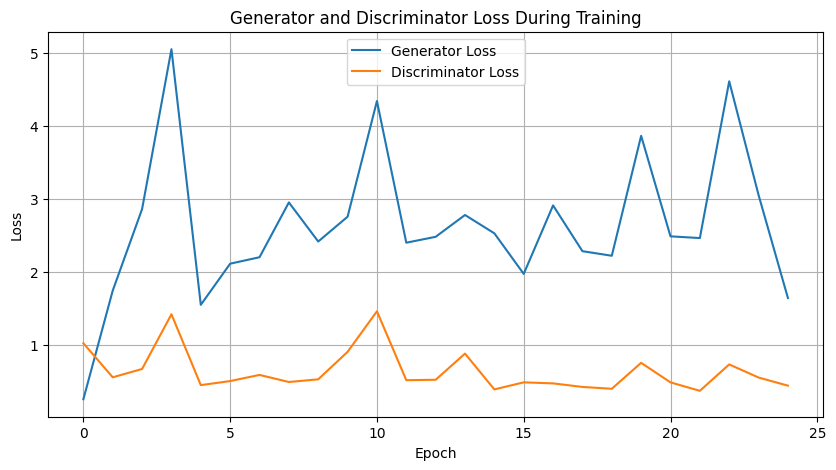

In [34]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

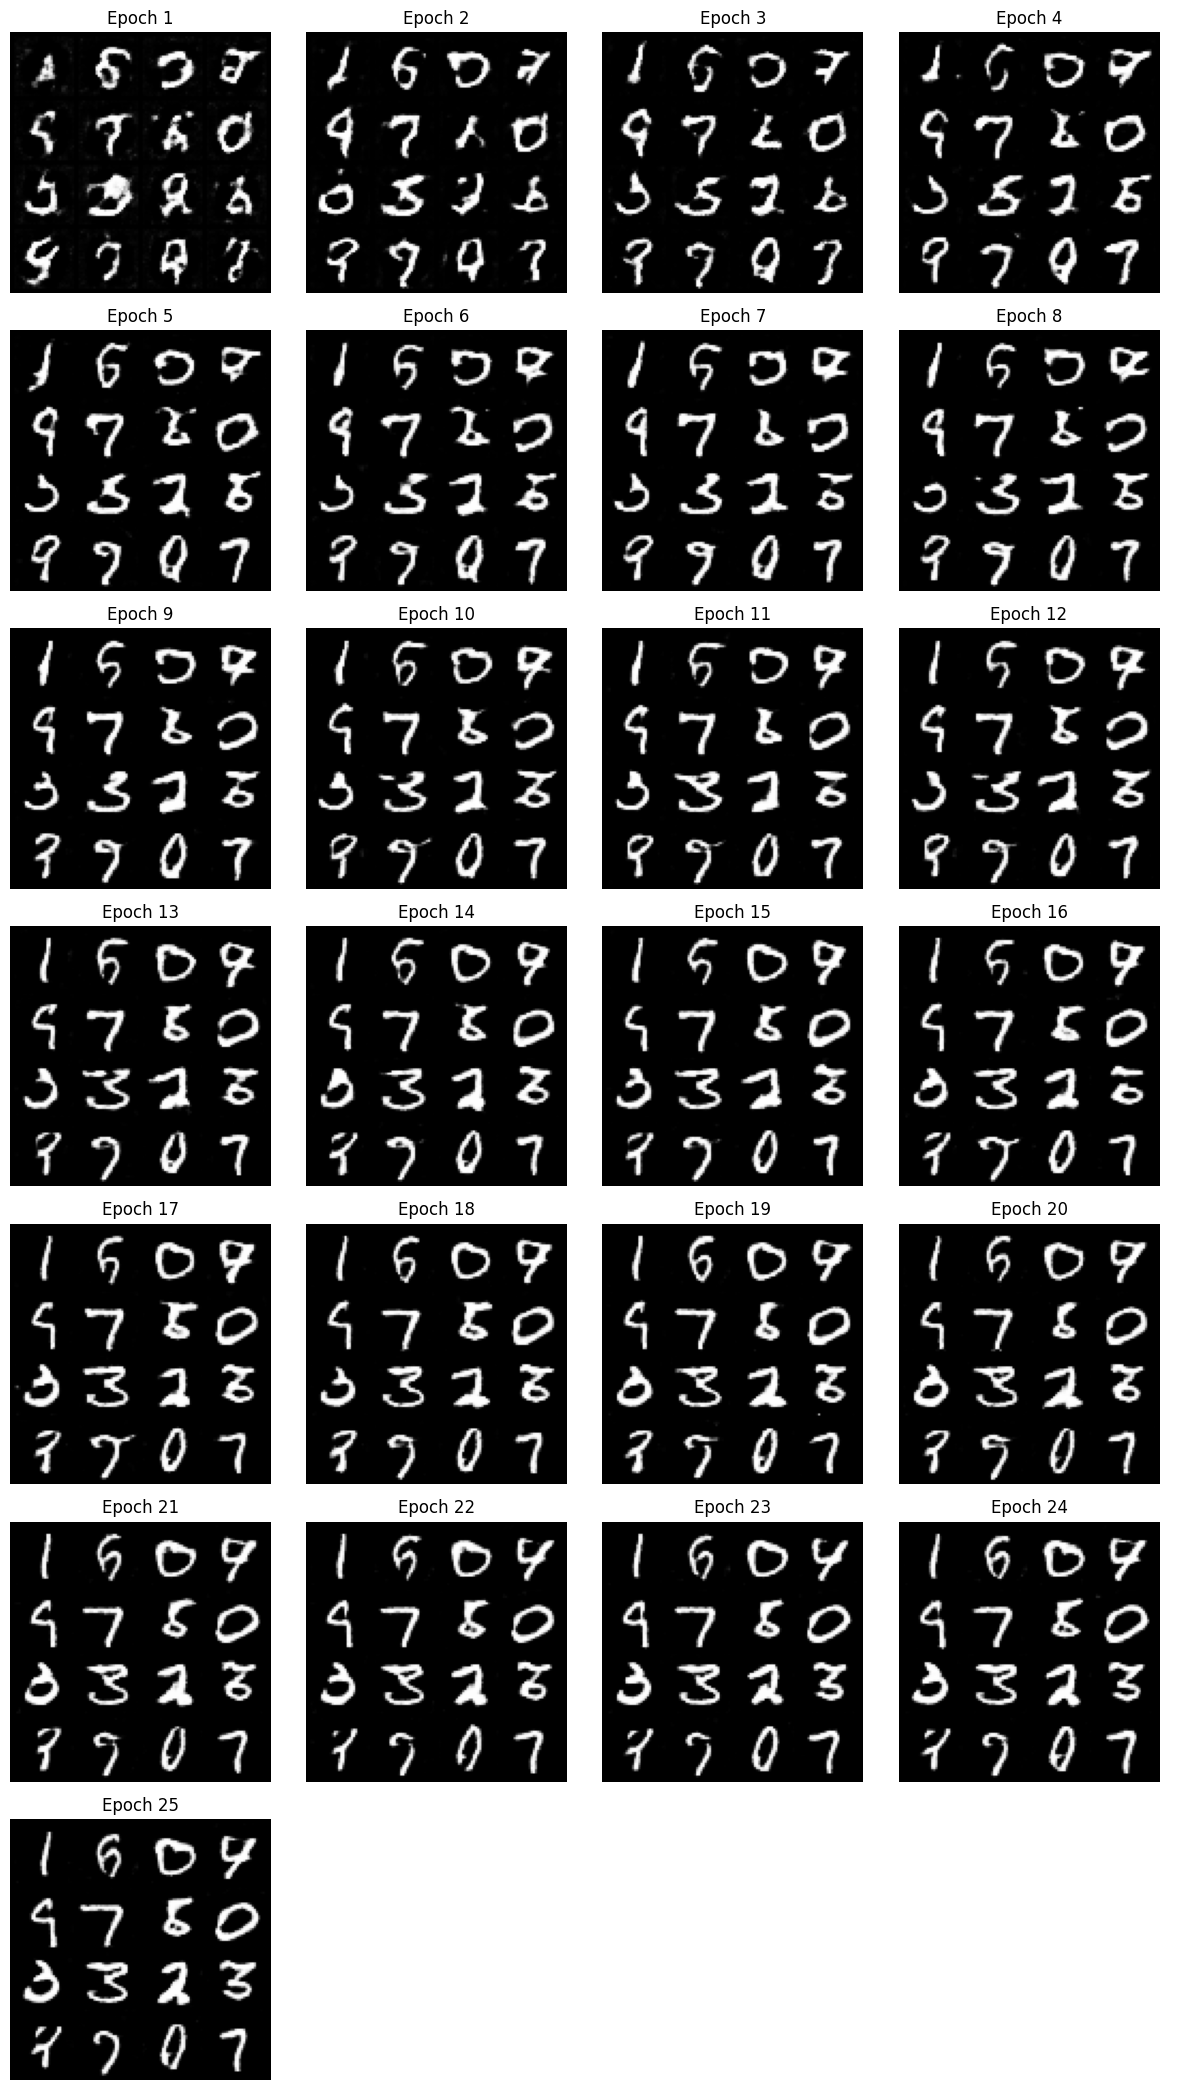

In [33]:
import math

num_epochs = len(epoch_images)
cols = 4
rows = math.ceil(num_epochs / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
axes = axes.flatten()

for epoch, images in enumerate(epoch_images):
    grid = torchvision.utils.make_grid(images, nrow=4, normalize=True)

    axes[epoch].imshow(np.transpose(grid, (1, 2, 0)))
    axes[epoch].set_title(f"Epoch {epoch+1}")
    axes[epoch].axis("off")

# Hide extra empty subplots
for i in range(num_epochs, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()